# Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval<br>every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>reporting | Objective | Prunning | MOO | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | |100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models | Running more epochs to get a better model |
|2 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose/Strict | All models | Saw overfitting, but didn't have the metric values |
|3 | |200 | 10,000 | 200 | `eval > 3` | Structural | Yes | None | Last  | Recall |Yes|No| Loose/Strict | - Full graph <br> - Dominant sets | Noticed that by running all 10,000 epocs had lower recall|
|4 | |200 | 4,000 | 50 | `eval > 3` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph  | Added early stoppage and best recall reporting to get better models |
|5 | |200 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph | We should include all reviews, not only the good ones<br>Light GCN is only about interactions. |
|6 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Since last model worked better for Full graph, running for all |
|7 |  |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Trained the random sets based on the best parameters for each the dominant set |
|8 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective |  Objective | Prunning | MOO  | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | | 100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Using iterations from 100K, results seem more consistent |
|2 |  | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models |Trained the random sets based on the best parameters <br>for each the dominant set as in the 100K |
|2 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |
 

In [15]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances, plot_pareto_front
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

#exp_name = 'e_100K'
exp_name = 'e_gowalla'
version=f'historic_results/{exp_name}/pass_0/'
#version=f'historic_results/sandbox/'
#version=''

In [16]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_gowalla_1c1dcs,0.174367,0.075633,0.009885,0.041770,0.176016,0.078234,0.010155,0.043152,27560.105608,160.319050,3.357730,29290,39944,368544,91039,91039,50,True,ndcg,1,96,0.000936,0.000002,3447,RMSprop,"[0.6837773323059082, 0.6280048489570618, 0.532...","[0.631283164024353, 0.6052938103675842, 0.5517...","[0.0005551549541146319, 0.004916058666057887, ...","[8.875343291580146e-05, 0.0006782101949226338,...","[0.00023008676309331554, 0.0028401362939071144...",0.075650,0.009888,0.041788,3600,False,2157.0,8739.0,10184.99209
1,e_gowalla_1c1dcs_rand1,0.134359,0.091813,0.011213,0.049494,0.136426,0.091985,0.011561,0.049974,24155.192181,162.035568,3.716260,29814,40847,368544,91039,91039,50,True,ndcg,1,96,0.001447,0.000123,1554,RMSprop,"[0.6760355830192566, 0.6526972055435181, 0.628...","[0.6314565539360046, 0.6171690821647644, 0.596...","[0.0005788581341006839, 0.0010945659169306816,...","[7.703128139862015e-05, 0.0001624355281666555,...","[0.00025229523514648674, 0.0005515728067367166...",0.091844,0.011226,0.049513,3900,False,NaN,NaN,NaN
2,e_gowalla_1c1dcs_rand2,0.135405,0.094573,0.011682,0.051717,0.137365,0.096718,0.012174,0.052825,29675.407165,165.564759,3.741304,29814,40847,368544,91039,91039,50,True,ndcg,1,128,0.001047,0.000003,2271,RMSprop,"[0.6705629825592041, 0.6512134671211243, 0.633...","[0.61235511302948, 0.6015199422836304, 0.58925...","[0.00034920934028220276, 0.0006467972538816475...","[6.530912988143882e-05, 0.00010549936365463192...","[0.00014280374663008704, 0.0003022122084675695...",0.094535,0.011682,0.051695,3950,False,NaN,NaN,NaN
3,e_gowalla_1c1dcs_rand3,0.081783,0.098133,0.011938,0.052791,0.084427,0.100920,0.012364,0.054403,28877.633168,178.931810,3.698490,29814,40847,368544,91039,91039,50,True,ndcg,1,256,0.001153,0.000002,1890,RMSprop,"[0.647685170173645, 0.6072559356689453, 0.5731...","[0.5424273014068604, 0.5214602947235107, 0.497...","[0.0004934762095017132, 0.0009211898943429952,...","[8.038046754638622e-05, 0.00013899122513229287...","[0.00023912039730859336, 0.0003813302873978167...",0.098131,0.011945,0.052816,3900,False,NaN,NaN,NaN
4,e_gowalla_1c1dcs_rand4,0.106454,0.093855,0.011421,0.050748,0.107587,0.097018,0.011926,0.052884,26918.884379,150.267784,3.680418,29814,40847,368544,91039,91039,50,True,ndcg,1,96,0.001951,0.000001,1712,Adam,"[0.6754904389381409, 0.6682969927787781, 0.658...","[0.6316227912902832, 0.6277782917022705, 0.621...","[0.0003263287533183611, 0.0005267140842776244,...","[6.363453680755577e-05, 9.71263982852167e-05, ...","[0.0001697300643221044, 0.0002560341093835532,...",0.093980,0.011431,0.050773,3150,True,NaN,NaN,NaN


## Losses for "Strict" DS Runs

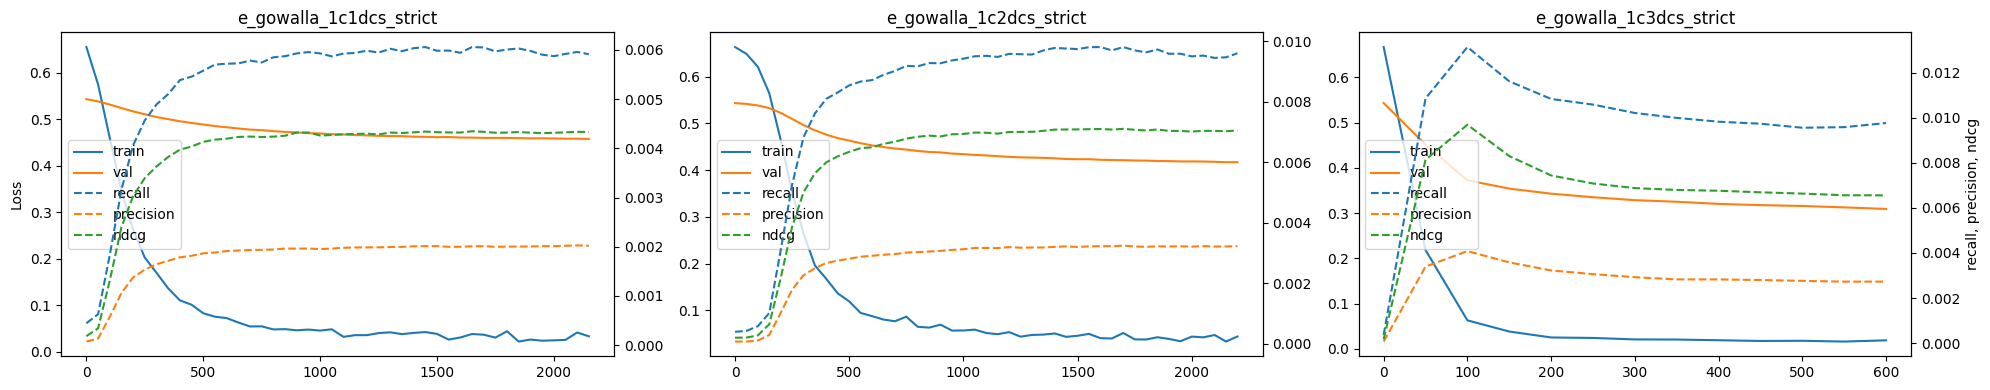

In [17]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

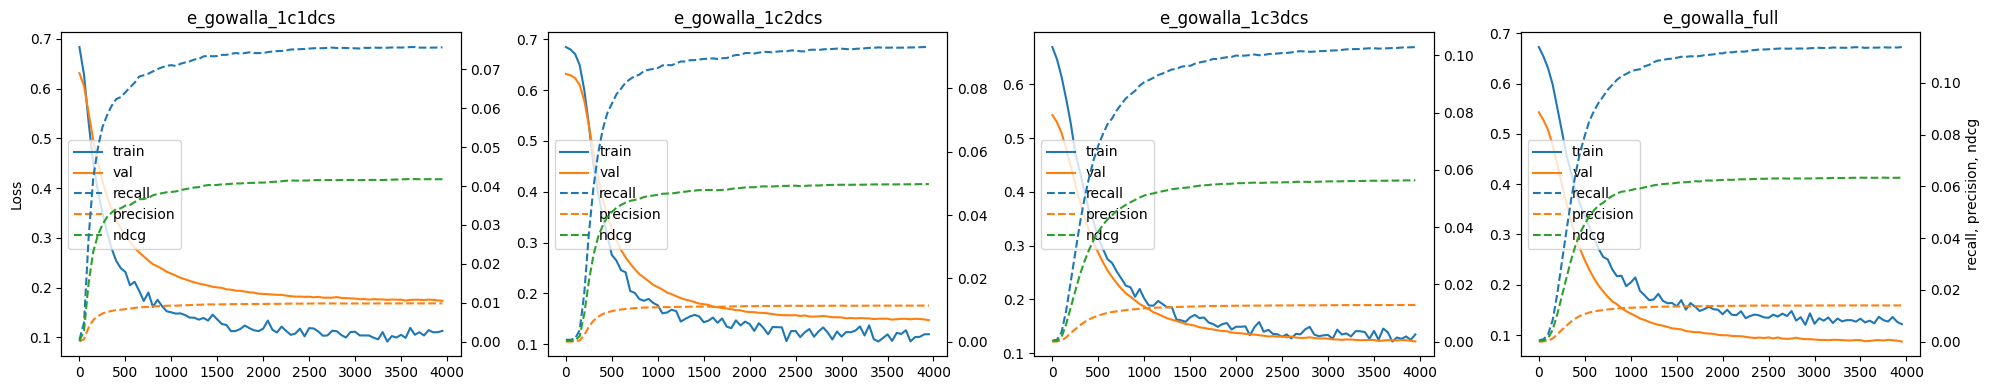

In [18]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Random runs losses for non-strict runs

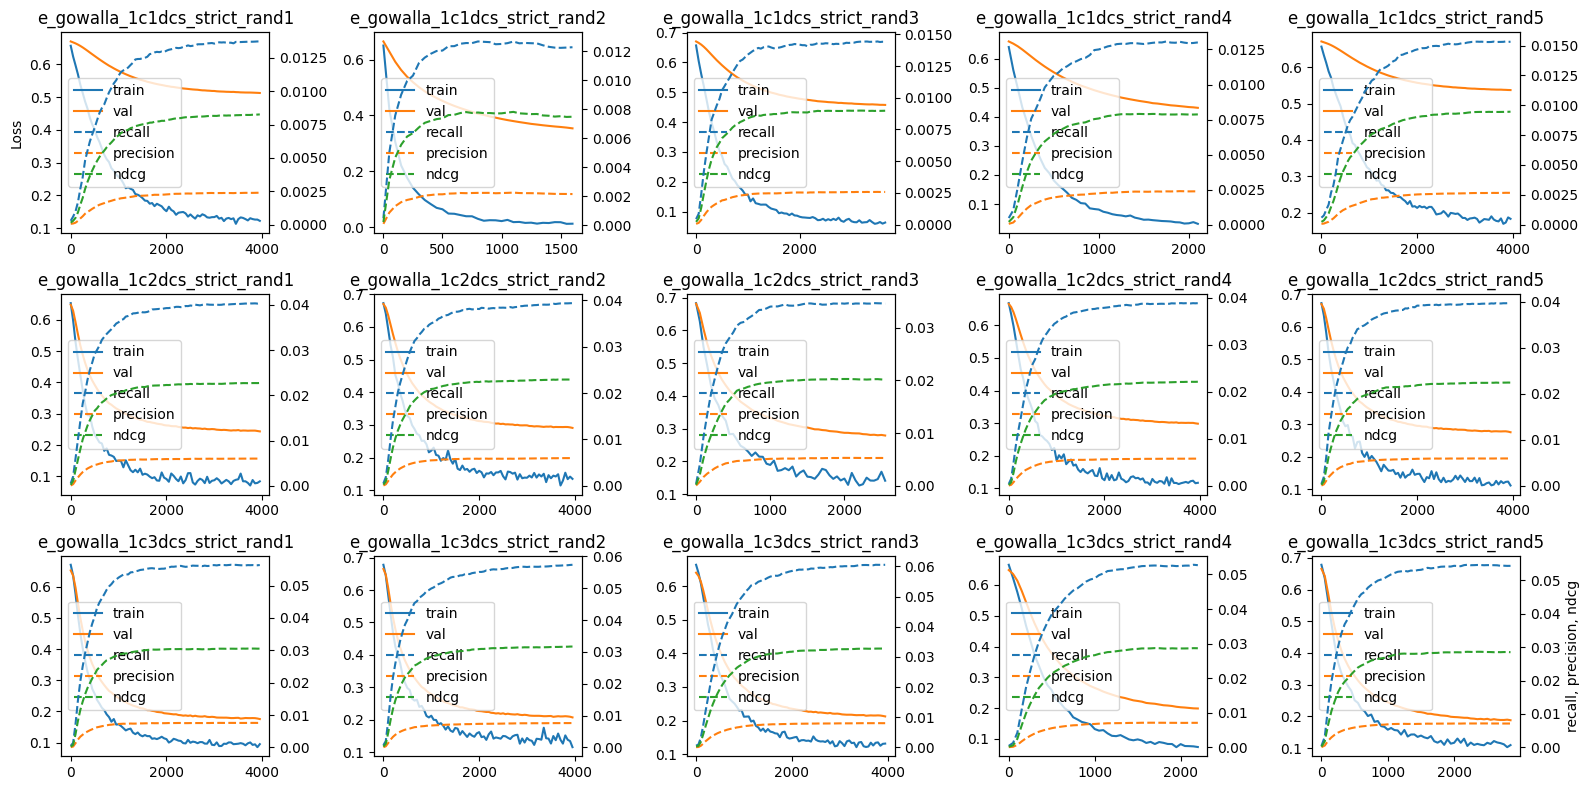

In [19]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict_rand.png')
plt.show()

## Random runs losses for non-strict runs

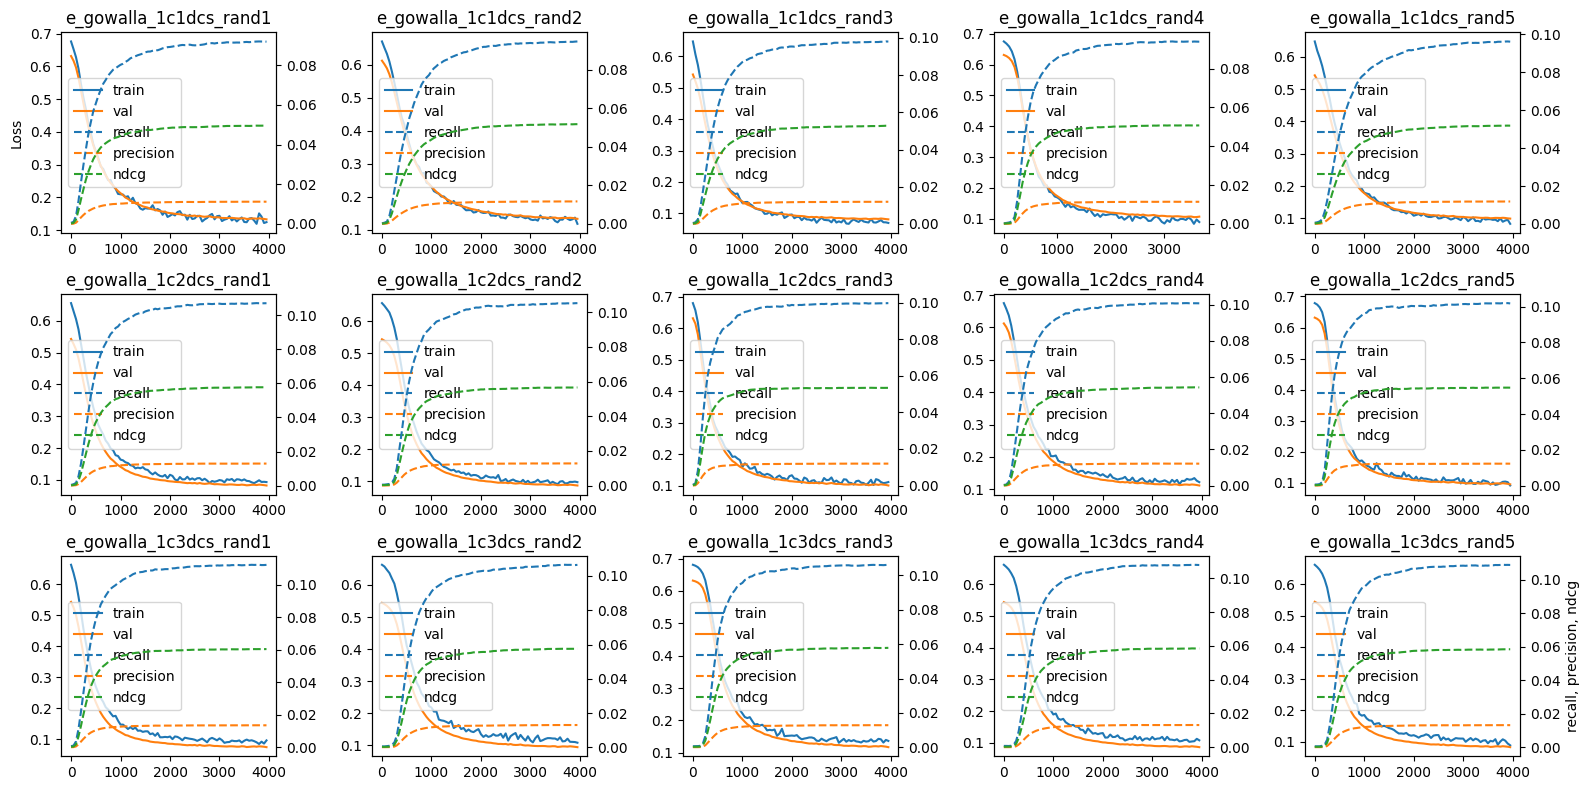

In [20]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose_rand.png')
plt.show()

## Trial analysis

In [21]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

objective_metric = df['objective_metric'].unique()[0]
objective_metric = objective_metric if objective_metric is not None else 'recall'
objective_metric_dict = {'recall':0, 'precision':1, 'ndcg':2}

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study, target=lambda t: t.values[objective_metric_dict[objective_metric]]) #added target for multi-objective
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,optimizer,lr,batch_size,n_layers,lambda_val,embedding_dim
e_gowalla_1c1dcs,0.841517,0.090666,0.031863,0.020644,0.008505,0.006805
e_gowalla_1c1dcs_strict,0.493159,0.021187,0.022429,0.387912,0.056460,0.018854
e_gowalla_1c2dcs,0.859334,0.027475,0.017350,0.033016,0.054826,0.007999
e_gowalla_1c2dcs_strict,0.628077,0.029148,0.019779,0.267197,0.046106,0.009693
e_gowalla_1c3dcs,0.690653,0.102755,0.022146,0.138673,0.035918,0.009854
e_gowalla_1c3dcs_strict,0.755715,0.021386,0.023782,0.152092,0.025862,0.021163
e_gowalla_full,0.768949,0.038951,0.043709,0.013277,0.051433,0.083681


In [22]:
studies = optuna.get_all_study_names(storage=f'sqlite:///{version}{exp_name}.sqlite3')

results = {}
for study_name in studies:
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')
    is_multi = len(study.directions) > 1

    trials = {}
    for trial in study.get_trials():
        parameters = trial.params
        parameters.update({'status': trial.state})
        parameters.update({'value': trial.values if is_multi else trial.value})
        parameters.update({'multi_objective':is_multi})
        trials[trial.number] = parameters

    results[study_name] = trials

flattened_data = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in results.items() 
    for inner_key, values in inner_dict.items()
}
flattened_data

trials_params = pd.DataFrame.from_dict(flattened_data, orient='index').reset_index(names=['study','trial'])
trials_params['status'] = trials_params['status'].map({x: str(TrialState(x)).split('.')[1].lower() for x in range(0,5)})
trials_params.head()


,study,trial,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,status,value,multi_objective
0,Study_e_gowalla_full,0,4,128,0.005321,0.074500,1726,SGD,complete,"[0.0005892972021959314, 7.870587447250318e-05,...",True
1,Study_e_gowalla_full,1,2,32,0.021147,0.006952,3385,Adam,complete,"[0.0210416252757553, 0.0024298345502043006, 0....",True
2,Study_e_gowalla_full,2,1,128,0.000327,0.025607,3410,Adam,complete,"[0.00047083401312285957, 7.870587447250318e-05...",True
3,Study_e_gowalla_full,3,2,32,0.056051,0.000609,1575,Adam,complete,"[0.026821930099092867, 0.0032554089356286423, ...",True
4,Study_e_gowalla_full,4,4,96,0.006109,0.000001,1276,RMSprop,complete,"[0.04138926189250355, 0.004769241074418917, 0....",True


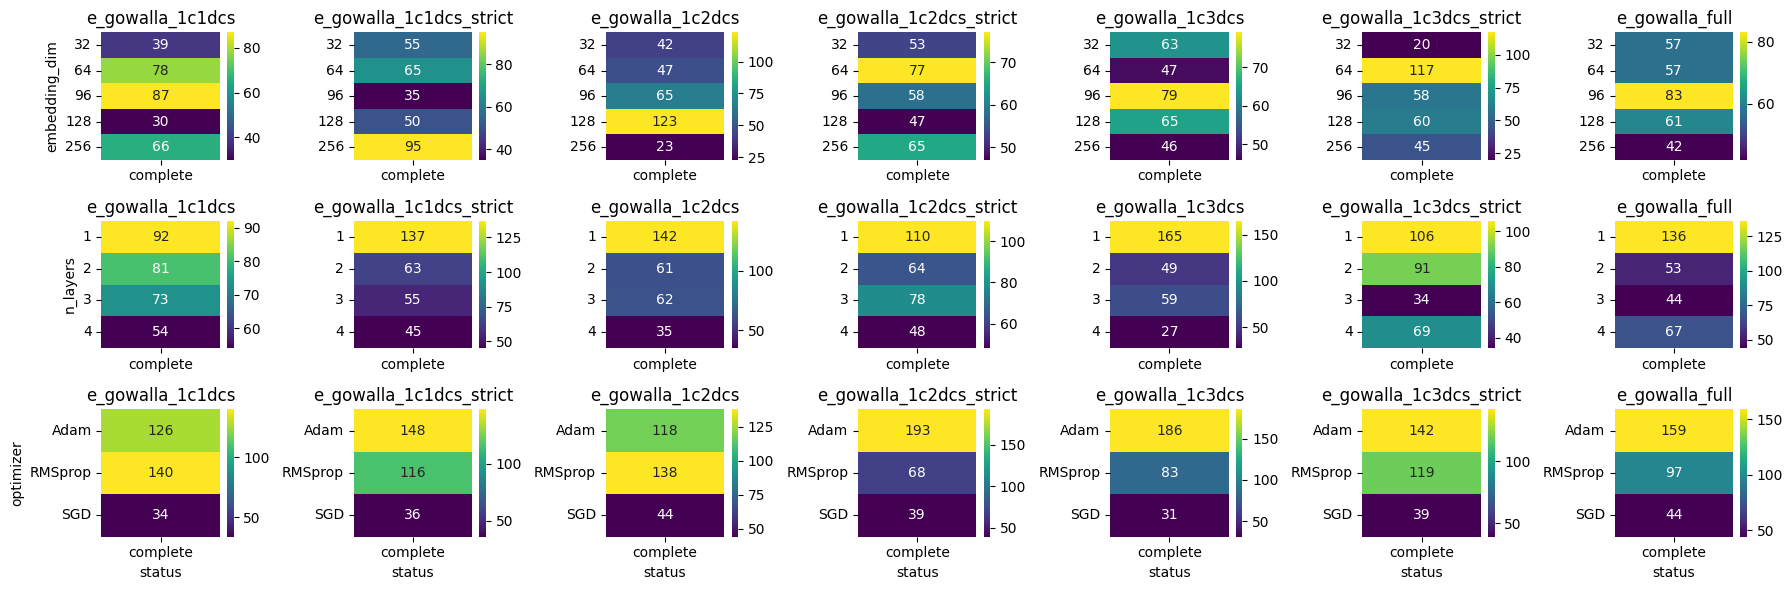

In [23]:
plt.figure(figsize=(18,6))
hyper_params = ['embedding_dim','n_layers','optimizer']

for j,param in enumerate(hyper_params):
    df_t = trials_params.groupby(['study','status',param]).count().reset_index()
    df_t = df_t[~df_t['study'].str.contains('_rand')]

    for i, study in enumerate(df_t['study'].unique()):
        plt.subplot(len(hyper_params),df_t['study'].nunique(),j*(df_t['study'].nunique())+i+1)
        plt.title(study[len('Study_'):])
        sub_df = df_t[df_t['study']==study]
        ax = sns.heatmap(sub_df.pivot(index=param, columns='status', values='trial'), cmap='viridis', annot=True, fmt='.0f')
        plt.yticks(rotation=0)

        if i != 0:
            ax.set(ylabel=None)
        
        if j != len(hyper_params)-1:
            ax.set(xlabel=None)

plt.tight_layout()
plt.savefig(version+'trials_hyperparmeters.png')
plt.show()

In [24]:
study_name = f'Study_{exp_name}_full'

if trials_params['multi_objective'].unique()[0]:
    print('Plotting pareto front ...')
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')

    best_trials = study.best_trials
    for trial in best_trials:
        print(f"Trial #{trial.number}: Values={trial.values}, Params={trial.params}")

    fig = plot_pareto_front(study, target_names=["Recall", "Precision","NDCG"])
    fig.update_layout(title=f"3D Pareto Front: {study_name}", width=800, height=800)
    fig.show()
else:
    print('Not a multi-objective run ... ')


Plotting pareto front ...
Trial #222: Values=[0.11419535803413876, 0.014106772054390785, 0.06460874798892755], Params={'n_layers': 1, 'embedding_dim': 256, 'lr': 0.0009463388507176841, 'lambda_val': 2.8807178813664366e-05, 'batch_size': 2234, 'optimizer': 'RMSprop'}


In [25]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}

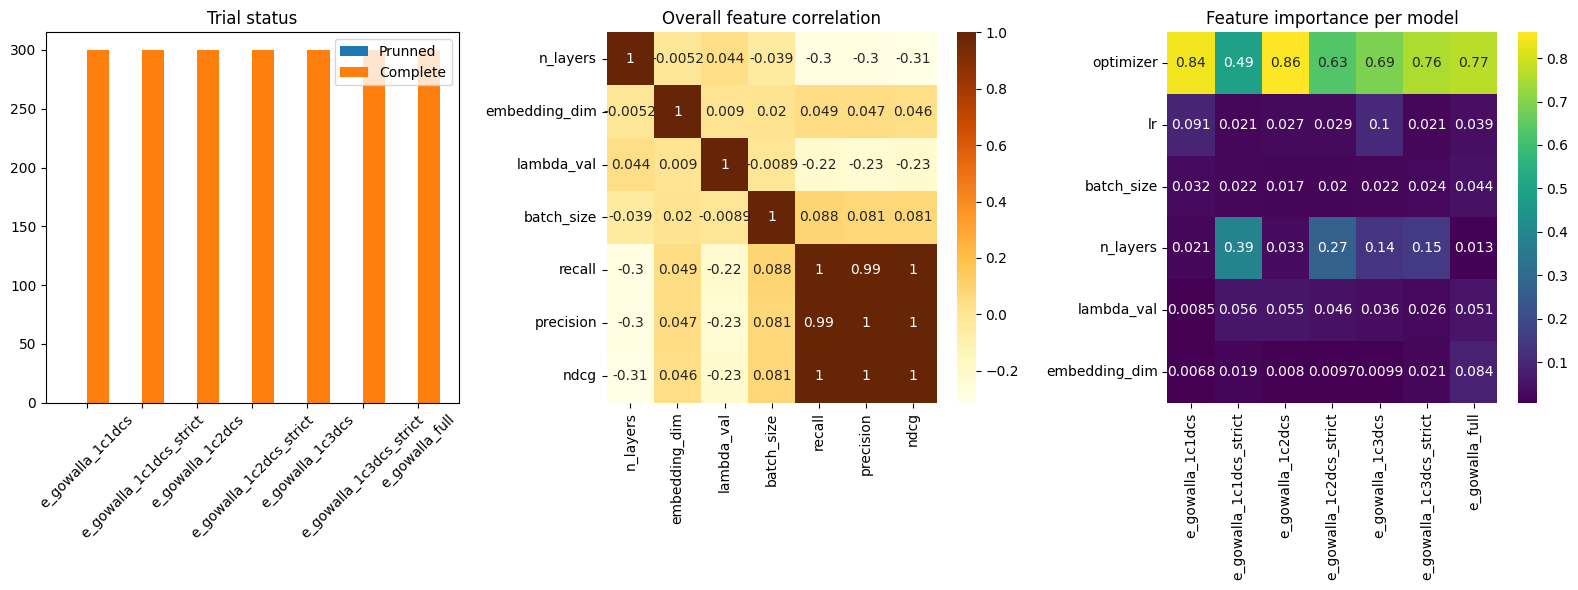

In [26]:
x = np.arange(len(trials_df))
width = 0.4

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index, rotation=45)

plt.title('Trial status')

plt.subplot(1,3,2)
if trials_params['multi_objective'].unique()[0]:
    sns.heatmap(trials_params.assign(recall=trials_params['value'].apply(pd.Series)[0], precision=trials_params['value'].apply(pd.Series)[1], ndcg=trials_params['value'].apply(pd.Series)[2])[['n_layers','embedding_dim','lambda_val','batch_size','recall','precision','ndcg']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')
else:
    sns.heatmap(trials_params[['n_layers','embedding_dim','lambda_val','batch_size','value']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')

plt.subplot(1,3,3)
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')

plt.tight_layout()
plt.savefig(version+'trials_feature_importance.png')
plt.show()

## Visualizations

In [27]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.174367,0.075633,0.009885,0.041770,0.176016,0.078234,0.010155,0.043152,0.075650,3600,False,27560.105608,160.319050,3.357730,10184.99209,368544,2157.0,8739.0,1,96,0.000936,0.000002,3447,RMSprop
1,1c1dcs_rand,0.134359,0.091813,0.011213,0.049494,0.136426,0.091985,0.011561,0.049974,0.091844,3900,False,24155.192181,162.035568,3.716260,NaN,368544,NaN,NaN,1,96,0.001447,0.000123,1554,RMSprop
2,1c1dcs_rand,0.135405,0.094573,0.011682,0.051717,0.137365,0.096718,0.012174,0.052825,0.094535,3950,False,29675.407165,165.564759,3.741304,NaN,368544,NaN,NaN,1,128,0.001047,0.000003,2271,RMSprop
3,1c1dcs_rand,0.081783,0.098133,0.011938,0.052791,0.084427,0.100920,0.012364,0.054403,0.098131,3900,False,28877.633168,178.931810,3.698490,NaN,368544,NaN,NaN,1,256,0.001153,0.000002,1890,RMSprop
4,1c1dcs_rand,0.106454,0.093855,0.011421,0.050748,0.107587,0.097018,0.011926,0.052884,0.093980,3150,True,26918.884379,150.267784,3.680418,NaN,368544,NaN,NaN,1,96,0.001951,0.000001,1712,Adam


In [28]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  11 days, 6:12:39.967512


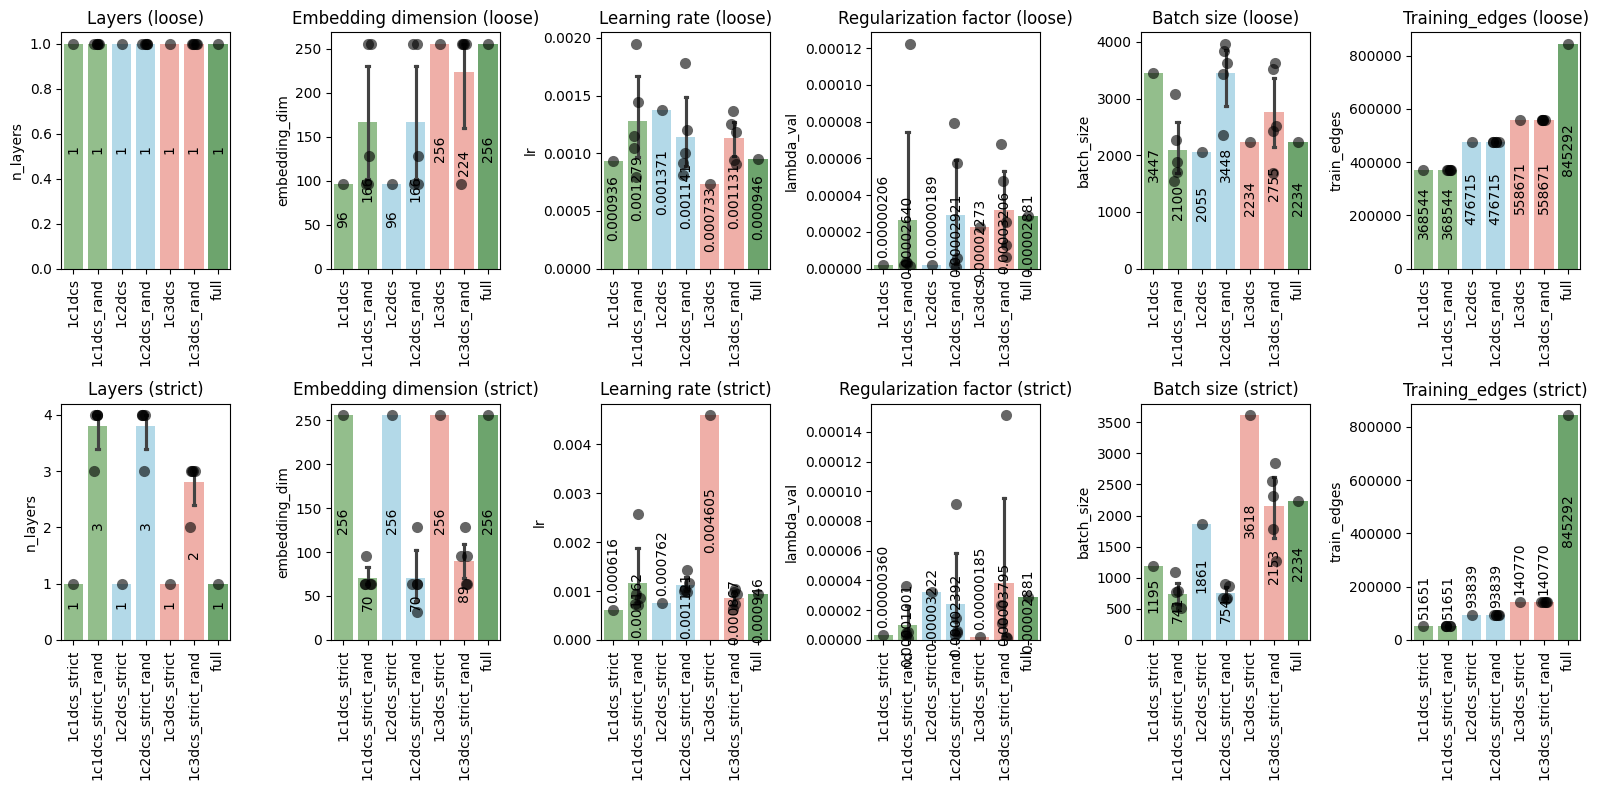

In [ ]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,strict in enumerate([False, True]):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)


plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()

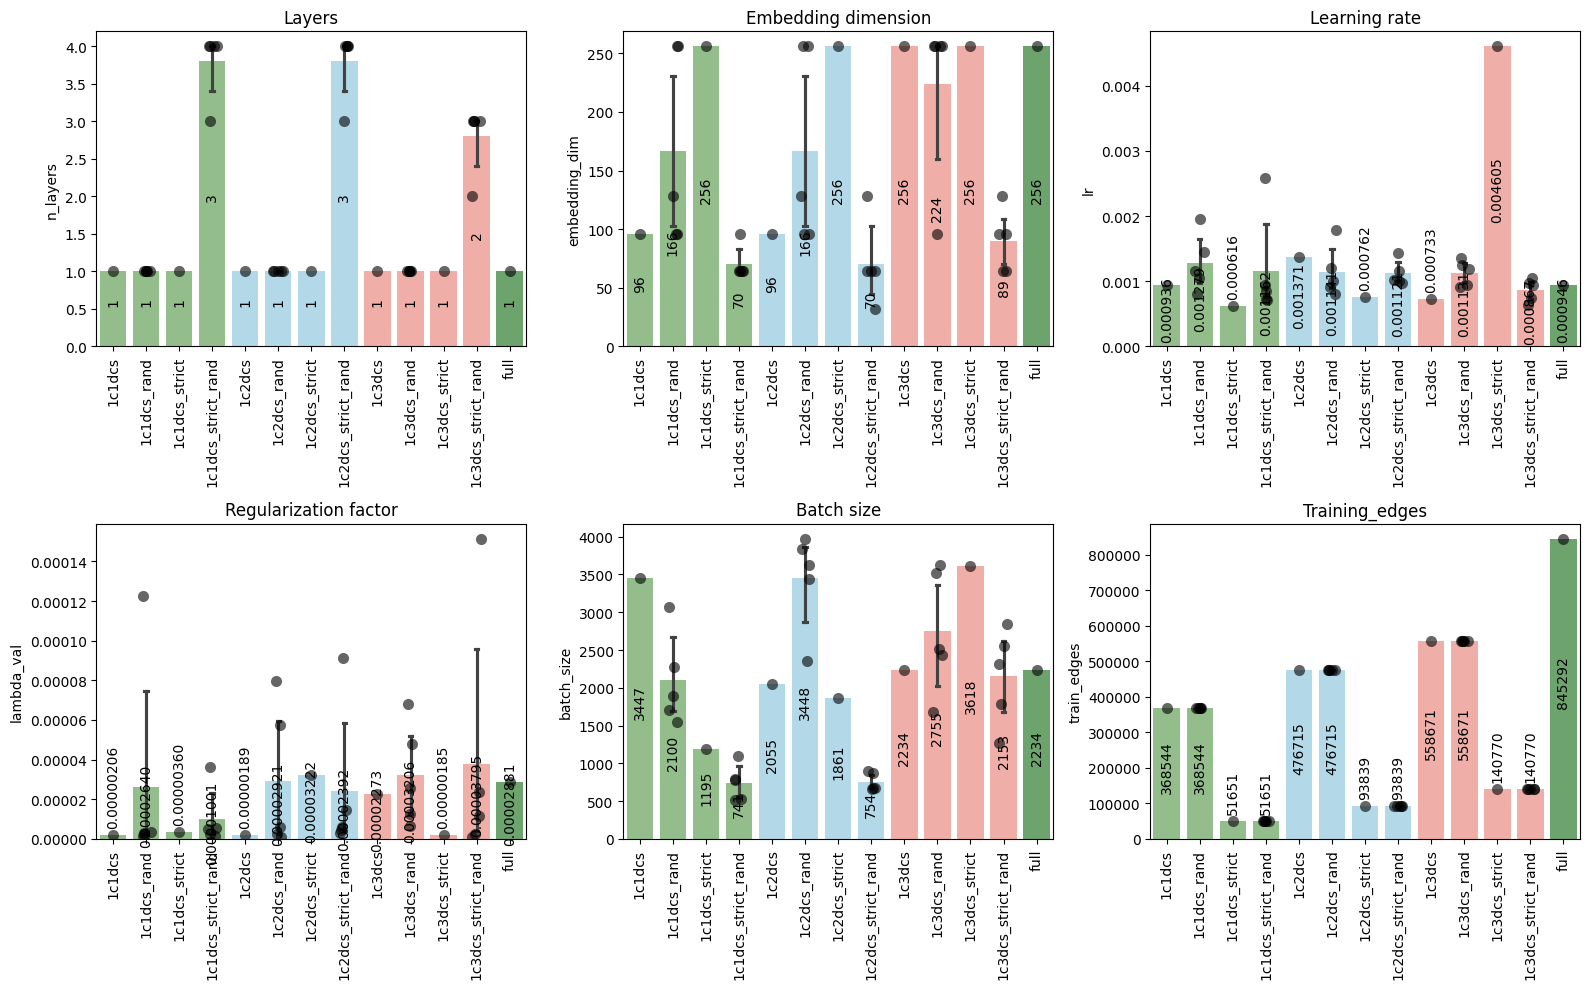

In [30]:

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])

plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

plt.figure(figsize=(16,10))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(n_plots_height,n_plots_wide,i+1)

    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()


In [31]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.174367,0.000000,0.075633,0.000000,0.009885,0.000000,0.041770,0.000000,0.176016,0.000000,0.078234,0.000000,0.010155,0.000000,0.043152,0.000000,0.075650,0.000000,3600.0,0.000000,0.0,0.000000,27560.105608,0.000000,160.319050,0.000000,3.357730,0.000000,10184.992090,0.0,368544.0,2157.0,8739.0,[1],[96],[0.000936097337950737],[2.061360640875514e-06],[3447],[RMSprop]
1,1c1dcs_rand,0.111685,0.023049,0.094909,0.002387,0.011620,0.000301,0.051319,0.001251,0.113618,0.022918,0.096948,0.003232,0.012059,0.000322,0.052710,0.001655,0.094937,0.002368,3760.0,341.686991,0.2,0.447214,28169.347850,2727.231286,167.640521,12.790882,3.717368,0.029089,0.000000,0.0,368544.0,0.0,0.0,[1],"[96, 128, 256]","[0.0014474267912490204, 0.0010470286775611781,...","[0.00012250709547244776, 2.8670388049392515e-0...","[1554, 2271, 1890, 1712, 3074]","[RMSprop, Adam]"
2,1c1dcs_strict,0.458327,0.000000,0.005913,0.000000,0.002020,0.000000,0.004334,0.000000,0.456689,0.000000,0.006775,0.000000,0.002262,0.000000,0.005154,0.000000,0.006058,0.000000,1650.0,0.000000,1.0,0.000000,15794.392357,0.000000,87.663052,0.000000,3.445190,0.000000,10184.992090,0.0,51651.0,2157.0,8739.0,[1],[256],[0.0006158877725370185],[3.6015692758113356e-06],[1195],[RMSprop]
3,1c1dcs_strict_rand,0.458716,0.072019,0.013751,0.001189,0.002431,0.000204,0.008410,0.000807,0.459602,0.071917,0.013617,0.001440,0.002455,0.000241,0.008195,0.000857,0.013824,0.001080,2750.0,1330.883165,0.6,0.547723,20192.968847,1879.000631,119.446648,42.211046,3.307448,0.117544,0.000000,0.0,51651.0,0.0,0.0,"[4, 3]","[64, 96]","[0.000710331438856921, 0.0025795756581398536, ...","[2.468073181110974e-06, 5.282448475572872e-06,...","[790, 528, 775, 1098, 516]",[RMSprop]
4,1c2dcs,0.149217,0.000000,0.093055,0.000000,0.011442,0.000000,0.049762,0.000000,0.150686,0.000000,0.095433,0.000000,0.011831,0.000000,0.051822,0.000000,0.092993,0.000000,3950.0,0.000000,0.0,0.000000,25873.835365,0.000000,161.780926,0.000000,3.604314,0.000000,10103.377103,0.0,476715.0,3483.0,10067.0,[1],[96],[0.0013714940045912373],[1.8909302902485554e-06],[2055],[Adam]


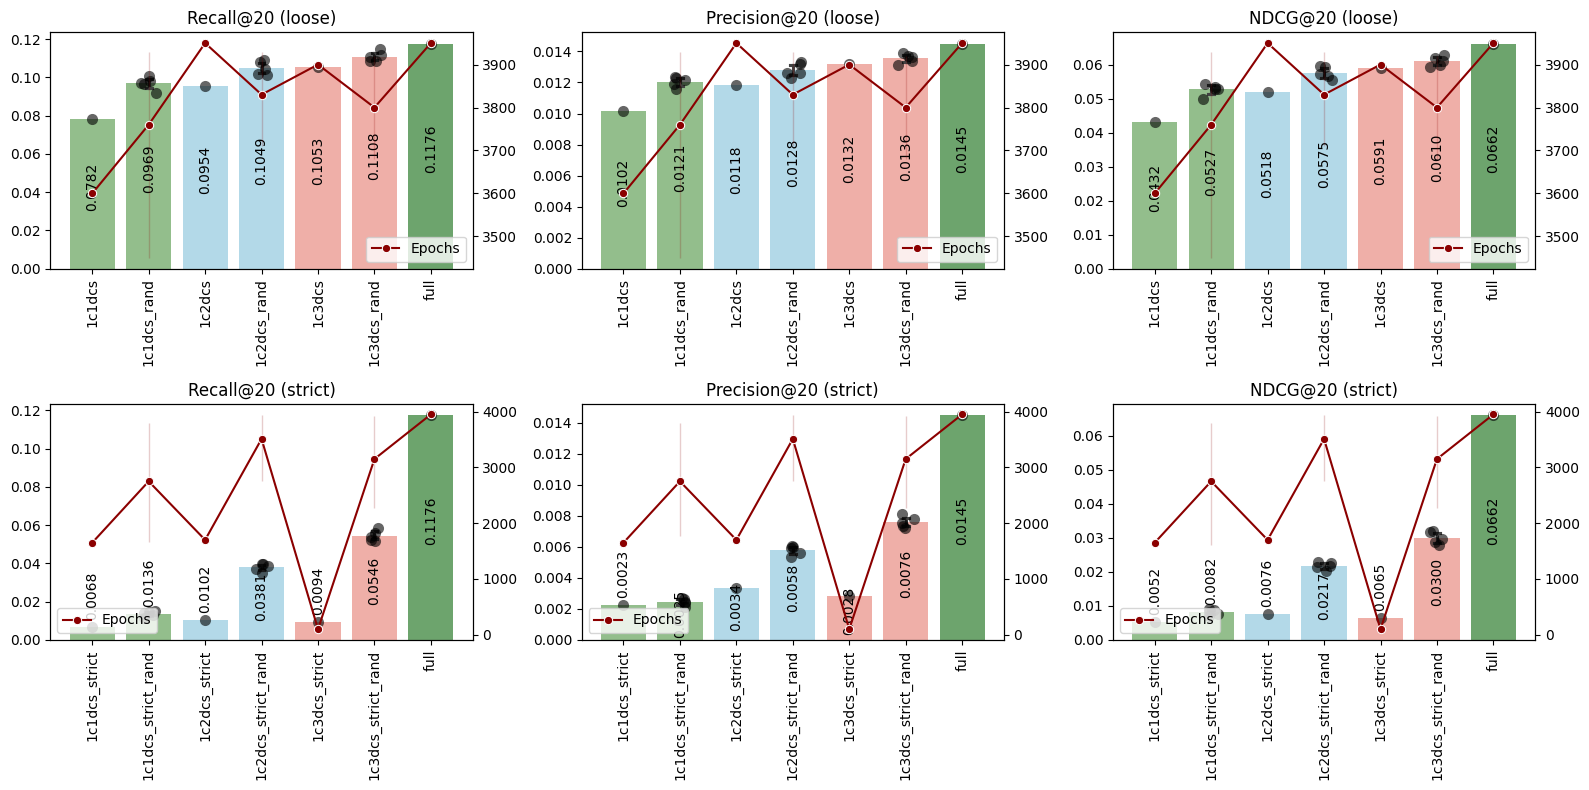

In [32]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

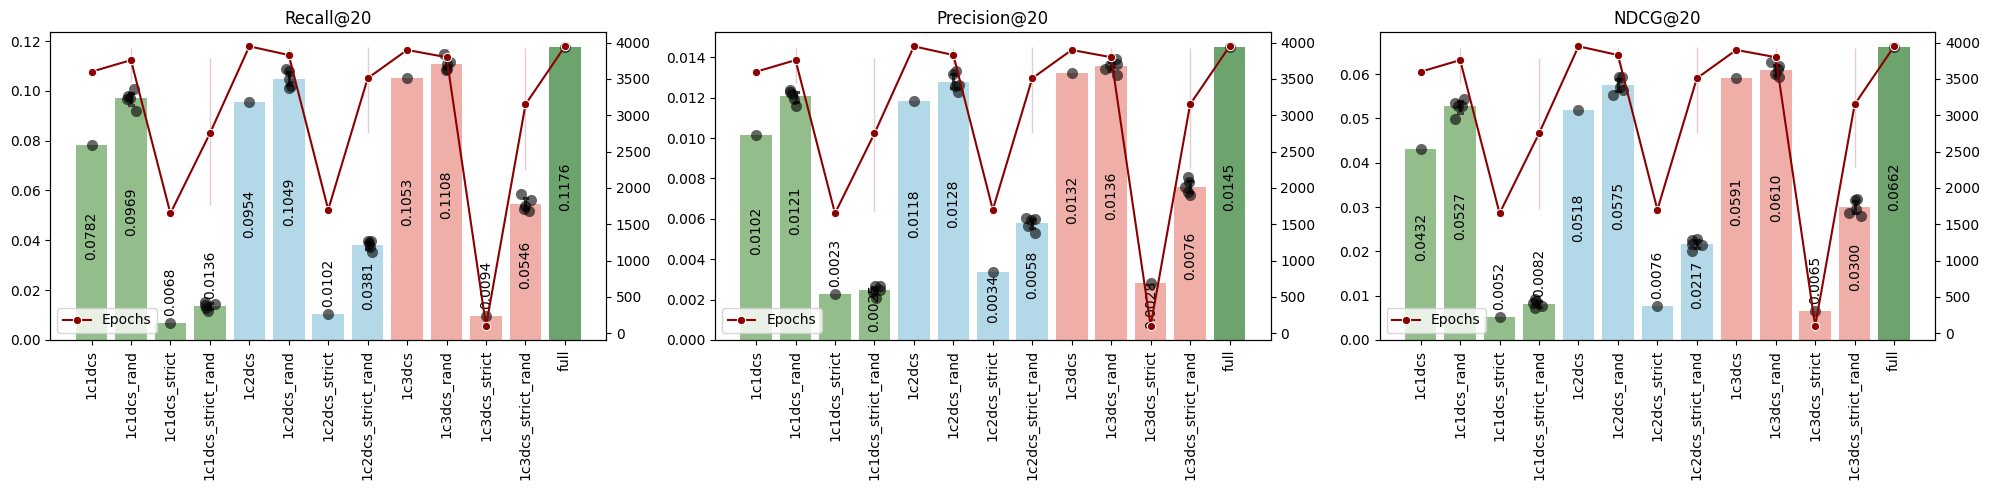

In [33]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

plt.figure(figsize=(20,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)
    
    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)

    ax2 = ax.twinx()
    #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
    if 'cycle' in random_experiments_stats.columns:
        sns.lineplot(data=random_experiments_stats, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
        ax2.set_ylabel('Training epochs')

    plt.title(titles[i])
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_metrics.png')
plt.show()

<Figure size 1600x1000 with 0 Axes>

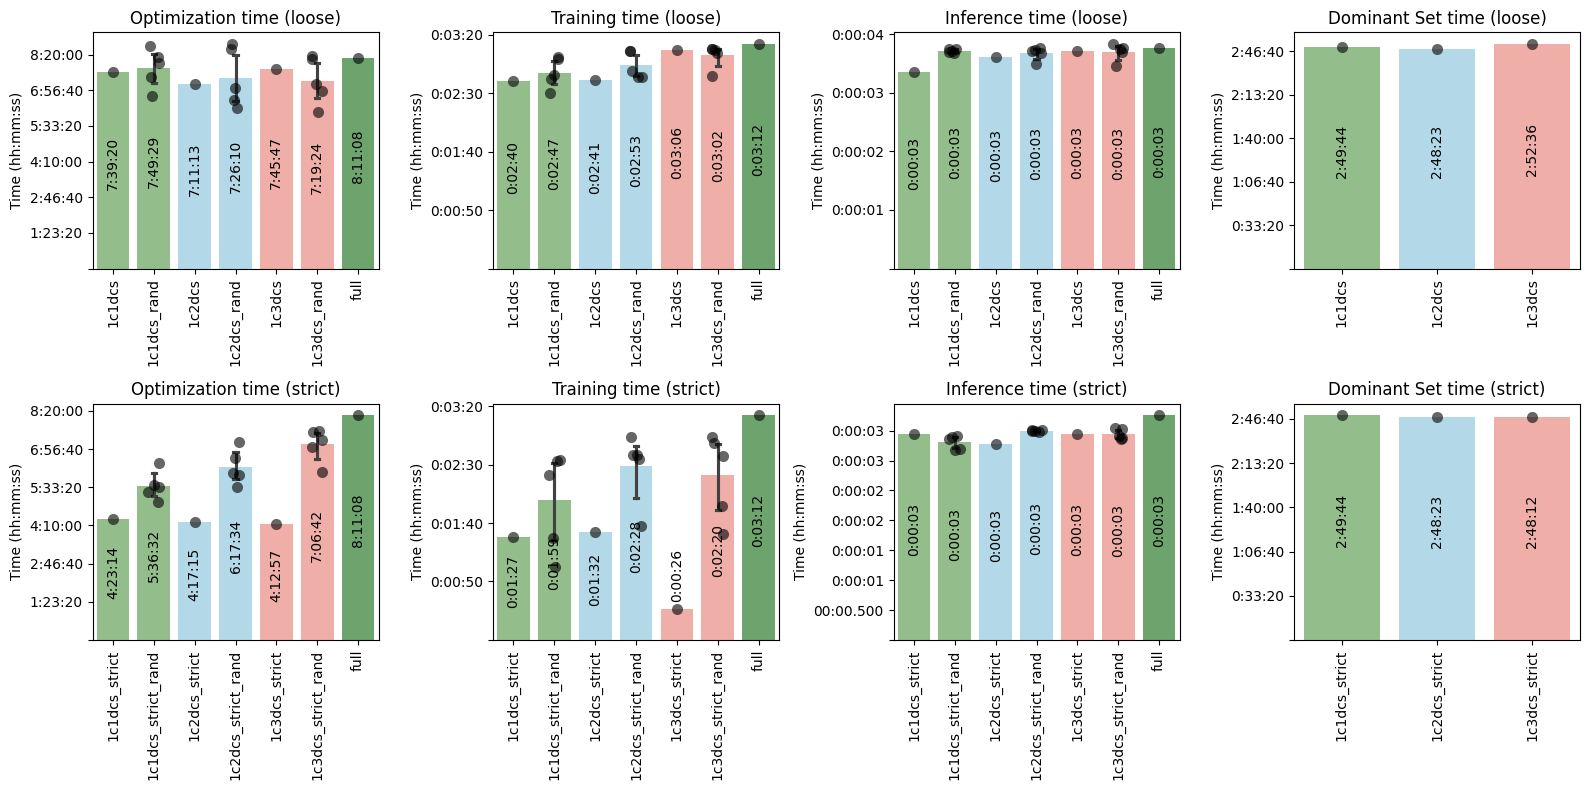

In [34]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]

        # Create the barplot
        ax = sns.barplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            errorbar=('ci', 95),
            capsize=0.1, 
            alpha=0.7, 
            palette=color_dict,  
            hue='experiment', 
            legend=False
        ) 

        # --- FIX FOR BAR LABELS ---
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        # --------------------------


        # Add the stripplot
        sns.stripplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            color='black', 
            size=8, 
            alpha=0.6, 
            jitter=0.15,
            ax=ax
        )
        
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

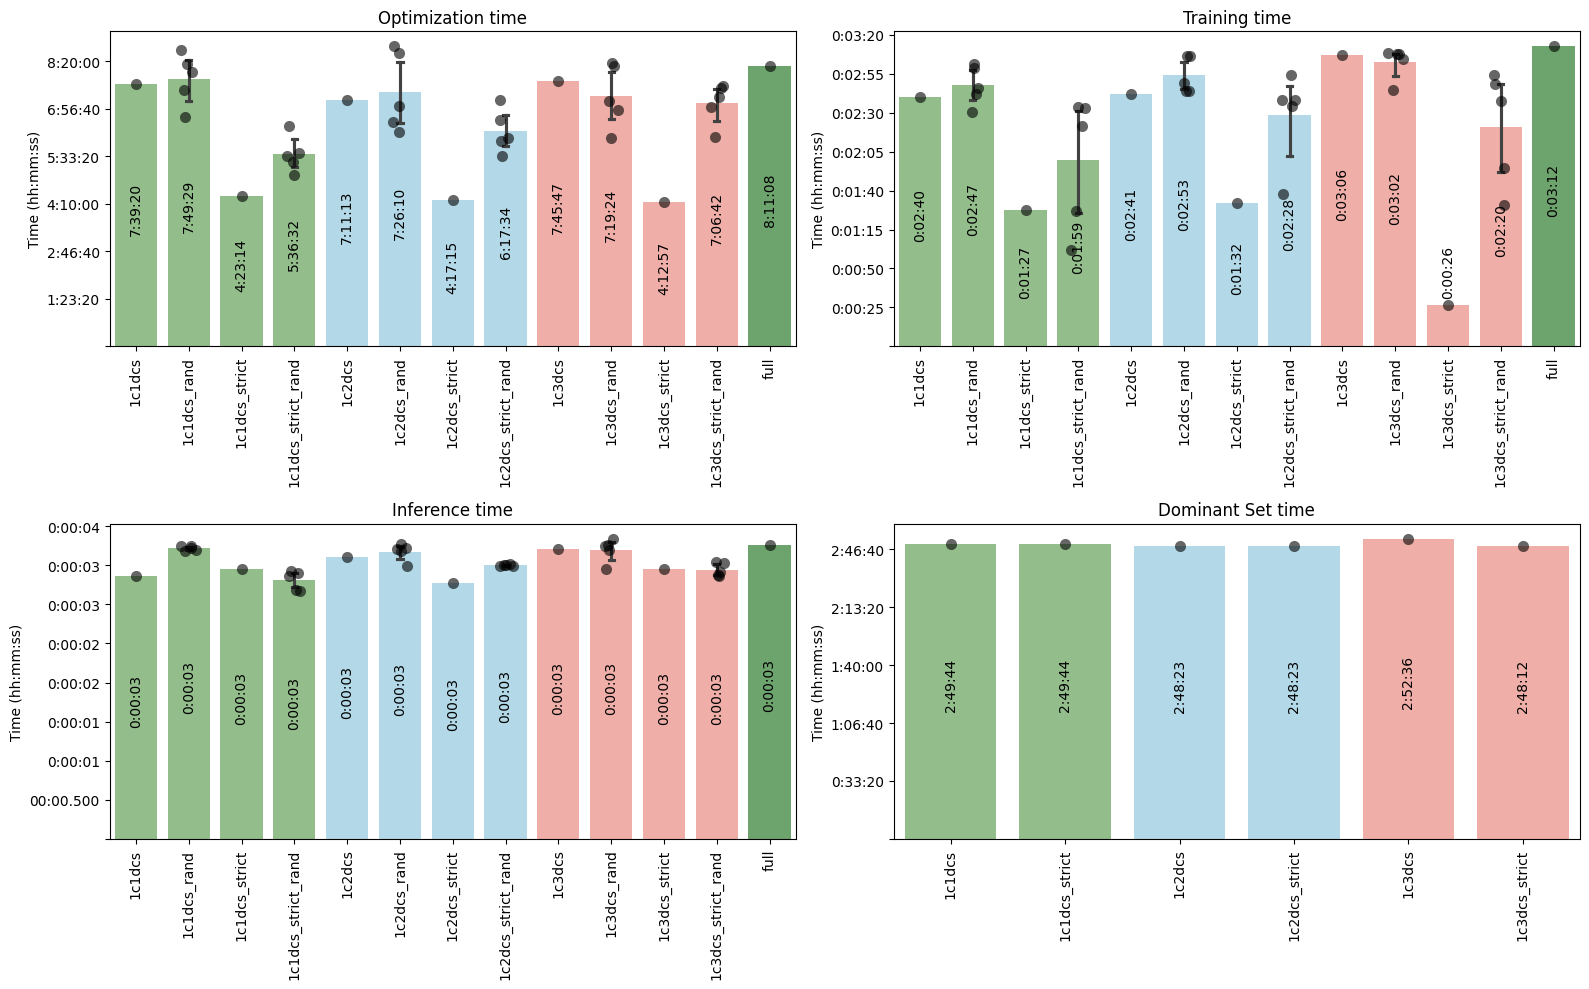

In [35]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i, metric in enumerate(plots):
    plt.subplot(n_plots_height, n_plots_wide, i+1)

    # Create the barplot
    ax = sns.barplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        errorbar=('ci', 95),
        capsize=0.1, 
        alpha=0.7, 
        palette=color_dict,  
        hue='experiment', 
        legend=False
    ) 

    # --- FIX FOR BAR LABELS ---
    # Iterate through all containers generated by Seaborn's hue
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        # Generate a label list directly from the bar heights in this specific container
        labels = [format_time(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    # --------------------------


    # Add the stripplot
    sns.stripplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        color='black', 
        size=8, 
        alpha=0.6, 
        jitter=0.15,
        ax=ax
    )
    
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

    # Use the mean of the actual current metric to decide the axis label
    current_mean = random_experiments_stats[metric].mean()
    if current_mean < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
#plt.savefig(version+'experiments_times.png')
plt.show()

In [36]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [37]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.1744,0.0756,0.0099,0.0418,0.1760,0.0782,0.0102,0.0432,0.0757,"3,600.0000",0.0000,368544.0,2157.0,8739.0,07:39:20,00:02:40,00:00:03,02:49:44,[1],[96],[0.000936097337950737],[2.061360640875514e-06],[3447],[RMSprop]
1,1c1dcs_rand,0.1117 ± 0.0230,0.0949 ± 0.0024,0.0116 ± 0.0003,0.0513 ± 0.0013,0.1136 ± 0.0229,0.0969 ± 0.0032,0.0121 ± 0.0003,0.0527 ± 0.0017,0.0949 ± 0.0024,"3,760.0000 ± 341.6870",0.2000 ± 0.4472,368544.0,0.0,0.0,07:49:29 ± 00:45:27,00:02:47 ± 00:00:12,00:00:03 ± 00:00:00,00:00:00,[1],"[96, 128, 256]","[0.0014474267912490204, 0.0010470286775611781,...","[0.00012250709547244776, 2.8670388049392515e-0...","[1554, 2271, 1890, 1712, 3074]","[RMSprop, Adam]"
2,1c1dcs_strict,0.4583,0.0059,0.0020,0.0043,0.4567,0.0068,0.0023,0.0052,0.0061,"1,650.0000",1.0000,51651.0,2157.0,8739.0,04:23:14,00:01:27,00:00:03,02:49:44,[1],[256],[0.0006158877725370185],[3.6015692758113356e-06],[1195],[RMSprop]
3,1c1dcs_strict_rand,0.4587 ± 0.0720,0.0138 ± 0.0012,0.0024 ± 0.0002,0.0084 ± 0.0008,0.4596 ± 0.0719,0.0136 ± 0.0014,0.0025 ± 0.0002,0.0082 ± 0.0009,0.0138 ± 0.0011,"2,750.0000 ± 1,330.8832",0.6000 ± 0.5477,51651.0,0.0,0.0,05:36:32 ± 00:31:19,00:01:59 ± 00:00:42,00:00:03 ± 00:00:00,00:00:00,"[4, 3]","[64, 96]","[0.000710331438856921, 0.0025795756581398536, ...","[2.468073181110974e-06, 5.282448475572872e-06,...","[790, 528, 775, 1098, 516]",[RMSprop]
4,1c2dcs,0.1492,0.0931,0.0114,0.0498,0.1507,0.0954,0.0118,0.0518,0.0930,"3,950.0000",0.0000,476715.0,3483.0,10067.0,07:11:13,00:02:41,00:00:03,02:48:23,[1],[96],[0.0013714940045912373],[1.8909302902485554e-06],[2055],[Adam]
5,1c2dcs_rand,0.0967 ± 0.0118,0.1029 ± 0.0032,0.0124 ± 0.0004,0.0554 ± 0.0018,0.0991 ± 0.0118,0.1049 ± 0.0034,0.0128 ± 0.0004,0.0575 ± 0.0018,0.1029 ± 0.0031,"3,830.0000 ± 144.0486",0.0000,476715.0,0.0,0.0,07:26:10 ± 01:09:16,00:02:53 ± 00:00:11,00:00:03 ± 00:00:00,00:00:00,[1],"[256, 96, 128]","[0.0008100924993836402, 0.0009985677820209626,...","[1.1284420006719815e-06, 7.94332667203252e-05,...","[3843, 3442, 3625, 3972, 2360]","[RMSprop, Adam]"
6,1c2dcs_strict,0.4169,0.0096,0.0032,0.0070,0.4165,0.0102,0.0034,0.0076,0.0098,"1,700.0000",1.0000,93839.0,3483.0,10067.0,04:17:15,00:01:32,00:00:03,02:48:23,[1],[256],[0.000762190113410319],[3.222265315337744e-05],[1861],[Adam]
7,1c2dcs_strict_rand,0.2792 ± 0.0210,0.0386 ± 0.0023,0.0058 ± 0.0003,0.0221 ± 0.0011,0.2807 ± 0.0207,0.0381 ± 0.0020,0.0058 ± 0.0003,0.0217 ± 0.0011,0.0386 ± 0.0023,"3,510.0000 ± 822.6482",0.2000 ± 0.4472,93839.0,0.0,0.0,06:17:34 ± 00:37:39,00:02:28 ± 00:00:29,00:00:03 ± 00:00:00,00:00:00,"[4, 3]","[128, 64, 32]","[0.0009791612272847586, 0.0010195306128642594,...","[1.471855561908882e-05, 2.99984087525946e-06, ...","[658, 678, 897, 674, 867]",[RMSprop]
8,1c3dcs,0.1232,0.1029,0.0128,0.0563,0.1251,0.1053,0.0132,0.0591,0.1028,"3,900.0000",0.0000,558671.0,4930.0,11638.0,07:45:47,00:03:06,00:00:03,02:52:36,[1],[256],[0.0007333136681919207],[2.2728319731025804e-05],[2234],[RMSprop]
9,1c3dcs_rand,0.0925 ± 0.0164,0.1082 ± 0.0024,0.0132 ± 0.0002,0.0585 ± 0.0011,0.0948 ± 0.0162,0.1108 ± 0.0025,0.0136 ± 0.0003,0.0610 ± 0.0014,0.1083 ± 0.0024,"3,800.0000 ± 150.0000",0.0000,558671.0,0.0,0.0,07:19:24 ± 00:55:05,00:03:02 ± 00:00:10,00:00:03 ± 00:00:00,00:00:00,[1],"[256, 96]","[0.0009052352884581927, 0.00125444020622911, 0...","[1.2588658448852132e-05, 6.806830251349438e-05...","[3521, 1686, 2519, 3624, 2428]","[RMSprop, Adam]"


# Conclusions and actions

## Symptoms
- Model is overfitting, given the train vs. val losses tracking (don't know about the performance metrics, since they haven't been captured.)
- Full graph is converging too fast, but train/val curves are  too far apart, system may have learned "too" quickly

## Suggested actions
- Add tracking for Recall, precision and NDCG (already did after current run.)
- Verify the random sample methods, since it only randomizes using train_test_split from sklearn, but sets may not be fully-connected or even coherent -> Rolando said this before.
    - Nos llevamos aristas siempre que embos nodos esten representados.
- After the right random sample calculate the dominant set from the sample set. --> from here sample random or structure preserving random.
    - The 5 random runs (absolute random), should sample from the random sample ONLY and maybe use a similar algorithm as the full random sample method, 
        - or maybe sample from the main sample with some other variation, limiting the total amount of rows
- Reduce the seach space for certain parameters (embedding_dim, remove the 32 option for instance, layers remove the 4 layers options) --> **Run 300 instances.**
    - Had done this before, but because of th randomization, we may have gotten a bad batch and seems to not converge.




In [ ]:
#import optuna

# Delete an entire study from the SQLite file
#optuna.delete_study(
#    study_name="Study_e_gowalla_1c3dcs_strict_rand5", 
#    storage="sqlite:///e_gowalla.sqlite3"
#)


/home/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#exp_name = 'e_gowalla'
#version=f'historic_results/{exp_name}/pass_3/'
#version=f'historic_results/sandbox/'
version=''

df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
1,e_gowalla_1c3dcs,0.123219,0.102850,0.012849,0.056328,0.125080,0.105309,0.013202,0.059108,27947.651534,186.940384,3.705962,29858,40947,558671,91039,91039,50,True,ndcg,1,256,0.000733,0.000023,2234,RMSprop,"[0.6694625616073608, 0.6467993259429932, 0.614...","[0.543046772480011, 0.5296653509140015, 0.5097...","[0.00043224275611599257, 0.0006715572208765116...","[6.363453680755577e-05, 9.880099135909974e-05,...","[0.00018430580128488724, 0.0003304528903878319...",0.102786,0.012844,0.056337,3900,False,4930.0,11638.0,10356.259005
2,e_gowalla_1c3dcs_rand1,0.076452,0.111987,0.013522,0.060339,0.078970,0.114624,0.013916,0.062783,25832.476977,187.288372,3.760080,29857,40976,558671,91039,91039,50,True,ndcg,1,256,0.000905,0.000013,3521,RMSprop,"[0.6618332862854004, 0.6355060935020447, 0.603...","[0.5425474643707275, 0.524687647819519, 0.5001...","[0.0007083030992997237, 0.001049658133810827, ...","[8.875343291580146e-05, 0.00013229285283676068...","[0.00029713228890830345, 0.0004931154045580917...",0.112121,0.013531,0.060372,3950,False,NaN,NaN,NaN
3,e_gowalla_1c3dcs_rand2,0.095553,0.106456,0.013010,0.057498,0.098000,0.108615,0.013408,0.059272,29785.495049,184.480554,3.690469,29857,40976,558671,91039,91039,50,True,ndcg,1,256,0.001254,0.000068,1686,Adam,"[0.6626893281936646, 0.6572093963623047, 0.646...","[0.5440398454666138, 0.5400092601776123, 0.534...","[0.0005419464716669989, 0.0005203234347076446,...","[8.875343291580147e-05, 8.875343291580146e-05,...","[0.0002605457585880334, 0.00025820070747334216...",0.106522,0.013015,0.057513,3650,False,NaN,NaN,NaN
4,e_gowalla_1c3dcs_rand3,0.119068,0.106118,0.012861,0.057870,0.121123,0.108564,0.013134,0.059949,24840.615631,164.492970,3.448323,29857,40976,558671,91039,91039,50,True,ndcg,1,96,0.001364,0.000048,2519,Adam,"[0.6807273030281067, 0.6778042912483215, 0.673...","[0.6318960785865784, 0.6295015811920166, 0.625...","[0.0005969269992565387, 0.0006625588905586715,...","[9.210261906356756e-05, 9.042802598968451e-05,...","[0.0003177486944830759, 0.0003136776518732734,...",0.106088,0.012874,0.057858,3650,False,NaN,NaN,NaN
5,e_gowalla_1c3dcs_rand4,0.087435,0.107834,0.013172,0.058483,0.089975,0.110610,0.013624,0.061075,21910.818689,188.240288,3.837275,29857,40976,558671,91039,91039,50,True,ndcg,1,256,0.000944,0.000025,3624,Adam,"[0.6617721319198608, 0.6549729704856873, 0.646...","[0.5437350273132324, 0.5396679639816284, 0.534...","[0.0008315736908576349, 0.0008321711239072715,...","[9.210261906356757e-05, 9.37772121374506e-05, ...","[0.00032292380375228567, 0.00035284965067534, ...",0.107946,0.013196,0.058492,3800,False,NaN,NaN,NaN


In [5]:
exp_name = 'e_gowalla'
version=f'historic_results/{exp_name}/pass_0/'
#version=f'historic_results/sandbox/'
#version=''

df2 = pd.read_parquet(f'{version}{exp_name}_first.parquet')
df2 = df2.sort_values('experiment', ascending=True)
eval_at_epochs = df2['epochs_per_eval'].unique()[0]
df2.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_gowalla_1c1dcs,0.174367,0.075633,0.009885,0.041770,0.176016,0.078234,0.010155,0.043152,27560.105608,160.319050,3.357730,29290,39944,368544,91039,91039,50,True,ndcg,1,96,0.000936,0.000002,3447,RMSprop,"[0.6837773323059082, 0.6280048489570618, 0.532...","[0.631283164024353, 0.6052938103675842, 0.5517...","[0.0005551549541146319, 0.004916058666057887, ...","[8.875343291580146e-05, 0.0006782101949226338,...","[0.00023008676309331554, 0.0028401362939071144...",0.075650,0.009888,0.041788,3600,False,2157.0,8739.0,10184.99209
8,e_gowalla_1c1dcs_rand1,0.134359,0.091813,0.011213,0.049494,0.136426,0.091985,0.011561,0.049974,24155.192181,162.035568,3.716260,29814,40847,368544,91039,91039,50,True,ndcg,1,96,0.001447,0.000123,1554,RMSprop,"[0.6760355830192566, 0.6526972055435181, 0.628...","[0.6314565539360046, 0.6171690821647644, 0.596...","[0.0005788581341006839, 0.0010945659169306816,...","[7.703128139862015e-05, 0.0001624355281666555,...","[0.00025229523514648674, 0.0005515728067367166...",0.091844,0.011226,0.049513,3900,False,NaN,NaN,NaN
9,e_gowalla_1c1dcs_rand2,0.135405,0.094573,0.011682,0.051717,0.137365,0.096718,0.012174,0.052825,29675.407165,165.564759,3.741304,29814,40847,368544,91039,91039,50,True,ndcg,1,128,0.001047,0.000003,2271,RMSprop,"[0.6705629825592041, 0.6512134671211243, 0.633...","[0.61235511302948, 0.6015199422836304, 0.58925...","[0.00034920934028220276, 0.0006467972538816475...","[6.530912988143882e-05, 0.00010549936365463192...","[0.00014280374663008704, 0.0003022122084675695...",0.094535,0.011682,0.051695,3950,False,NaN,NaN,NaN
10,e_gowalla_1c1dcs_rand3,0.081783,0.098133,0.011938,0.052791,0.084427,0.100920,0.012364,0.054403,28877.633168,178.931810,3.698490,29814,40847,368544,91039,91039,50,True,ndcg,1,256,0.001153,0.000002,1890,RMSprop,"[0.647685170173645, 0.6072559356689453, 0.5731...","[0.5424273014068604, 0.5214602947235107, 0.497...","[0.0004934762095017132, 0.0009211898943429952,...","[8.038046754638622e-05, 0.00013899122513229287...","[0.00023912039730859336, 0.0003813302873978167...",0.098131,0.011945,0.052816,3900,False,NaN,NaN,NaN
11,e_gowalla_1c1dcs_rand4,0.106454,0.093855,0.011421,0.050748,0.107587,0.097018,0.011926,0.052884,26918.884379,150.267784,3.680418,29814,40847,368544,91039,91039,50,True,ndcg,1,96,0.001951,0.000001,1712,Adam,"[0.6754904389381409, 0.6682969927787781, 0.658...","[0.6316227912902832, 0.6277782917022705, 0.621...","[0.0003263287533183611, 0.0005267140842776244,...","[6.363453680755577e-05, 9.71263982852167e-05, ...","[0.0001697300643221044, 0.0002560341093835532,...",0.093980,0.011431,0.050773,3150,True,NaN,NaN,NaN


In [ ]:
#joint_df = pd.concat([df2, df], axis=0)
#joint_df = joint_df.sort_values('experiment', ascending=True).reset_index(drop=True)

In [ ]:
#version=f'historic_results/{exp_name}/pass_0/'
#joint_df.to_parquet(f'{version}{exp_name}2.parquet')